In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [2]:
df = pd.read_csv("../data/processed/climate_cleaned.csv")

df.head()

,Date,City,State,Temperature_Max (°C),Temperature_Min (°C),Temperature_Avg (°C),Humidity (%),Rainfall (mm),Wind_Speed (km/h),AQI,AQI_Category,Pressure (hPa),Cloud_Cover (%),Year,Month,Day,Day_of_Week,Day_Name,Temperature_Range (°C),Humidity_Temperature_Index
0,2024-01-01,Mumbai,Maharashtra,32.5,18.0,25.2,77.6,0.0,3.3,259,Poor,1020.3,62.1,2024,1,1,0,Monday,14.5,1955.52
1,2024-01-01,Delhi,Delhi,25.4,10.7,18.1,84.1,0.0,9.0,130,Moderate,1008.4,46.0,2024,1,1,0,Monday,14.7,1522.21
2,2024-01-01,Bengaluru,Karnataka,37.2,30.8,34.0,49.0,3.7,6.6,54,Satisfactory,1008.0,61.3,2024,1,1,0,Monday,6.4,1666.00
3,2024-01-01,Chennai,Tamil Nadu,37.2,30.4,33.8,34.2,9.5,9.0,176,Moderate,993.4,70.0,2024,1,1,0,Monday,6.8,1155.96
4,2024-01-01,Kolkata,West Bengal,27.4,17.5,22.5,32.2,9.1,9.2,97,Satisfactory,1008.2,56.9,2024,1,1,0,Monday,9.9,724.50


Dataset Shape: (7310, 20)

Columns:
['Date', 'City', 'State', 'Temperature_Max (°C)', 'Temperature_Min (°C)', 'Temperature_Avg (°C)', 'Humidity (%)', 'Rainfall (mm)', 'Wind_Speed (km/h)', 'AQI', 'AQI_Category', 'Pressure (hPa)', 'Cloud_Cover (%)', 'Year', 'Month', 'Day', 'Day_of_Week', 'Day_Name', 'Temperature_Range (°C)', 'Humidity_Temperature_Index']

Data Types:
Date                           object
City                           object
State                          object
Temperature_Max (°C)          float64
Temperature_Min (°C)          float64
Temperature_Avg (°C)          float64
Humidity (%)                  float64
Rainfall (mm)                 float64
Wind_Speed (km/h)             float64
AQI                             int64
AQI_Category                   object
Pressure (hPa)                float64
Cloud_Cover (%)               float64
Year                            int64
Month                           int64
Day                             int64
Day_of_Week             

In [4]:
print("All Columns:")
for i, col in enumerate(df.columns):
    print(i, "->", col)

All Columns:
0 -> Date
1 -> City
2 -> State
3 -> Temperature_Max (°C)
4 -> Temperature_Min (°C)
5 -> Temperature_Avg (°C)
6 -> Humidity (%)
7 -> Rainfall (mm)
8 -> Wind_Speed (km/h)
9 -> AQI
10 -> AQI_Category
11 -> Pressure (hPa)
12 -> Cloud_Cover (%)
13 -> Year
14 -> Month
15 -> Day
16 -> Day_of_Week
17 -> Day_Name
18 -> Temperature_Range (°C)
19 -> Humidity_Temperature_Index


In [5]:
print("AQI Category Values:")
print(df["AQI_Category"].value_counts())

print("\nUnique values:")
print(df["AQI_Category"].unique())

AQI Category Values:
AQI_Category
Moderate        2385
Poor            2344
Satisfactory    1194
Very Poor       1136
Good             251
Name: count, dtype: int64

Unique values:
['Poor' 'Moderate' 'Satisfactory' 'Very Poor' 'Good']


seperation of x and y

In [6]:
# Target variable
target = "AQI_Category"

# Columns that must NOT be used as features
# AQI is excluded to avoid data leakage
drop_columns = [
    target,
    "AQI",
    "Date",
    "Day_Name"
]

X = df.drop(columns=drop_columns)
y = df[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

Features:
['City', 'State', 'Temperature_Max (°C)', 'Temperature_Min (°C)', 'Temperature_Avg (°C)', 'Humidity (%)', 'Rainfall (mm)', 'Wind_Speed (km/h)', 'Pressure (hPa)', 'Cloud_Cover (%)', 'Year', 'Month', 'Day', 'Day_of_Week', 'Temperature_Range (°C)', 'Humidity_Temperature_Index']

Target:
AQI_Category

X Shape: (7310, 16)
y Shape: (7310,)


check data leakage

In [7]:
print("Checking possible data leakage...\n")

print("Target column present in X:", target in X.columns)
print("AQI column present in X:", "AQI" in X.columns)

print("\nFinal feature columns:")
for col in X.columns:
    print("-", col)

Checking possible data leakage...

Target column present in X: False
AQI column present in X: False

Final feature columns:
- City
- State
- Temperature_Max (°C)
- Temperature_Min (°C)
- Temperature_Avg (°C)
- Humidity (%)
- Rainfall (mm)
- Wind_Speed (km/h)
- Pressure (hPa)
- Cloud_Cover (%)
- Year
- Month
- Day
- Day_of_Week
- Temperature_Range (°C)
- Humidity_Temperature_Index


categorical columns ko identify karna 

In [8]:
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()
numeric_columns = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Features:")
print(categorical_columns)

print("\nNumeric Features:")
print(numeric_columns)

Categorical Features:
['City', 'State']

Numeric Features:
['Temperature_Max (°C)', 'Temperature_Min (°C)', 'Temperature_Avg (°C)', 'Humidity (%)', 'Rainfall (mm)', 'Wind_Speed (km/h)', 'Pressure (hPa)', 'Cloud_Cover (%)', 'Year', 'Month', 'Day', 'Day_of_Week', 'Temperature_Range (°C)', 'Humidity_Temperature_Index']


Train test split data

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (5848, 16)
Testing data: (1462, 16)

Training target distribution:
AQI_Category
Moderate        1908
Poor            1875
Satisfactory     955
Very Poor        909
Good             201
Name: count, dtype: int64

Testing target distribution:
AQI_Category
Moderate        477
Poor            469
Satisfactory    239
Very Poor       227
Good             50
Name: count, dtype: int64


Data preprocessing pipeline

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()
numeric_columns = X.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: ['Temperature_Max (°C)', 'Temperature_Min (°C)', 'Temperature_Avg (°C)', 'Humidity (%)', 'Rainfall (mm)', 'Wind_Speed (km/h)', 'Pressure (hPa)', 'Cloud_Cover (%)', 'Year', 'Month', 'Day', 'Day_of_Week', 'Temperature_Range (°C)', 'Humidity_Temperature_Index']
Categorical columns: ['City', 'State']


model ko ready krna

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

print("Models prepared:")
for name in models:
    print("-", name)

Models prepared:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting


models ko train kare ge

In [12]:
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


Model evaluation + Comparison

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, pipeline in trained_models.items():

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    )
    roc_auc = roc_auc_score(
        y_test,
        y_proba,
        multi_class="ovr",
        average="weighted"
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.335157,0.216717,0.335157,0.261875,0.503806
1,Decision Tree,0.254446,0.252380,0.254446,0.253280,0.493361
2,Gradient Boosting,0.309166,0.236650,0.309166,0.248726,0.494363
3,Random Forest,0.309166,0.224568,0.309166,0.246186,0.504226


In [14]:
print("MODEL COMPARISON")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.3352,0.2167,0.3352,0.2619,0.5038
1,Decision Tree,0.2544,0.2524,0.2544,0.2533,0.4934
2,Gradient Boosting,0.3092,0.2367,0.3092,0.2487,0.4944
3,Random Forest,0.3092,0.2246,0.3092,0.2462,0.5042


detailed classify report

In [15]:
from sklearn.metrics import classification_report

for name, pipeline in trained_models.items():

    y_pred = pipeline.predict(X_test)

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

        Good       0.00      0.00      0.00        50
    Moderate       0.34      0.60      0.43       477
        Poor       0.33      0.44      0.38       469
Satisfactory       0.00      0.00      0.00       239
   Very Poor       0.00      0.00      0.00       227

    accuracy                           0.34      1462
   macro avg       0.13      0.21      0.16      1462
weighted avg       0.22      0.34      0.26      1462


Decision Tree
              precision    recall  f1-score   support

        Good       0.00      0.00      0.00        50
    Moderate       0.32      0.34      0.33       477
        Poor       0.30      0.29      0.30       469
Satisfactory       0.18      0.18      0.18       239
   Very Poor       0.14      0.14      0.14       227

    accuracy                           0.25      1462
   macro avg       0.19      0.19      0.19      1462
weighted avg       0.25      0.25      0.

Confusion matrix

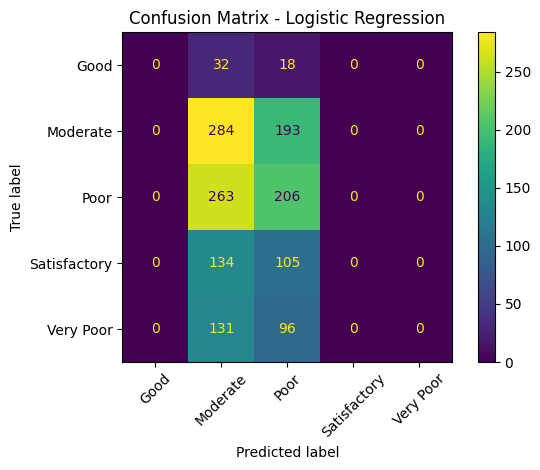

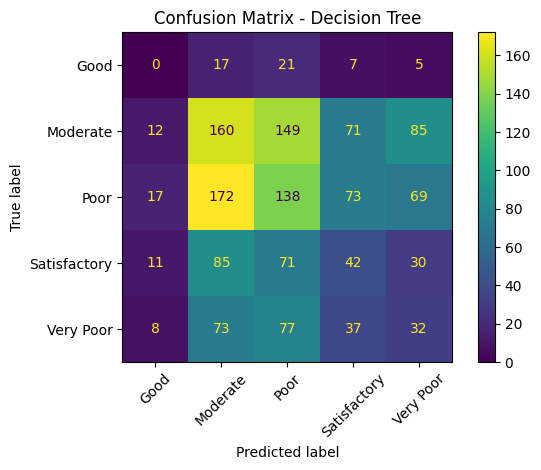

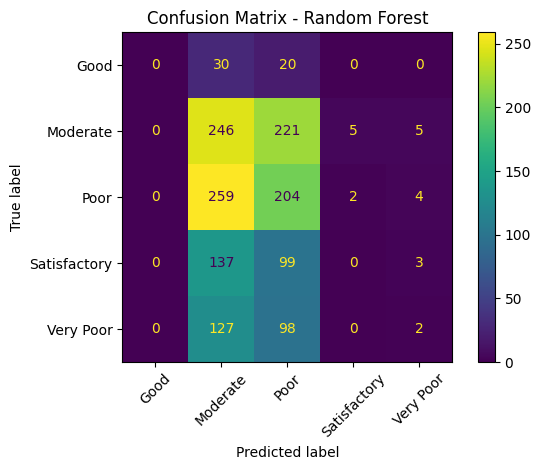

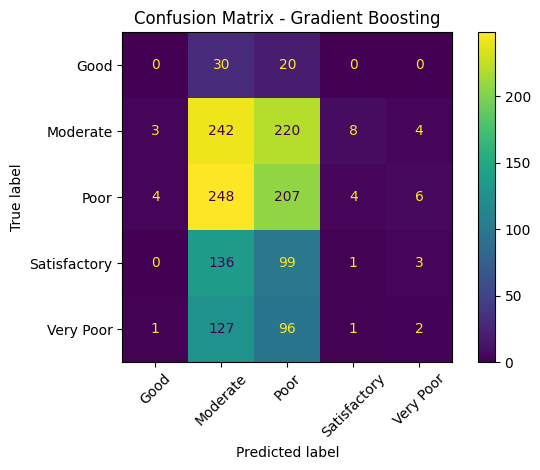

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

for name, pipeline in trained_models.items():

    y_pred = pipeline.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        xticks_rotation=45
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

choose best model

In [17]:
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

print("\nBest Model Performance:")
print(
    results_df.loc[
        results_df["Model"] == best_model_name
    ].to_string(index=False)
)

Best Model: Logistic Regression

Best Model Performance:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.335157   0.216717 0.335157  0.261875 0.503806


Best Model ko tune karna

In [18]:
from sklearn.model_selection import GridSearchCV

if best_model_name == "Random Forest":

    param_grid = {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5]
    }

elif best_model_name == "Decision Tree":

    param_grid = {
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    }

elif best_model_name == "Logistic Regression":

    param_grid = {
        "model__C": [0.1, 1, 10],
        "model__solver": ["lbfgs"]
    }

elif best_model_name == "Gradient Boosting":

    param_grid = {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3]
    }

tuning = GridSearchCV(
    estimator=trained_models[best_model_name],
    param_grid=param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

tuning.fit(X_train, y_train)

print("Best Parameters:")
print(tuning.best_params_)

print("\nBest CV F1-Score:")
print(tuning.best_score_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best Parameters:
{'model__C': 1, 'model__solver': 'lbfgs'}

Best CV F1-Score:
0.2513819216749568


Tuned model

In [19]:
final_model = tuning.best_estimator_

print("Final Model:", best_model_name)
print("Tuned model trained successfully.")

Final Model: Logistic Regression
Tuned model trained successfully.


Final test predictions

In [20]:
final_pred = final_model.predict(X_test)
final_proba = final_model.predict_proba(X_test)

final_accuracy = accuracy_score(y_test, final_pred)

final_precision = precision_score(
    y_test,
    final_pred,
    average="weighted",
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_pred,
    average="weighted",
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_pred,
    average="weighted",
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    final_proba,
    multi_class="ovr",
    average="weighted"
)

print("FINAL MODEL PERFORMANCE")
print("=" * 50)
print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))
print("F1-Score :", round(final_f1, 4))
print("ROC-AUC  :", round(final_roc_auc, 4))

FINAL MODEL PERFORMANCE
Accuracy : 0.3352
Precision: 0.2167
Recall   : 0.3352
F1-Score : 0.2619
ROC-AUC  : 0.5038


Sample predictions values

In [21]:
prediction_results = X_test.copy()

prediction_results["Actual_AQI_Category"] = y_test.values
prediction_results["Predicted_AQI_Category"] = final_pred

prediction_results[
    ["Actual_AQI_Category", "Predicted_AQI_Category"]
].head(20)

,Actual_AQI_Category,Predicted_AQI_Category
5935,Poor,Poor
2034,Poor,Poor
6524,Satisfactory,Poor
1469,Poor,Poor
2839,Satisfactory,Moderate
2787,Poor,Moderate
3073,Poor,Moderate
5810,Poor,Moderate
5225,Poor,Poor
6614,Moderate,Poor


classification report

In [22]:
print(classification_report(
    y_test,
    final_pred,
    zero_division=0
))

              precision    recall  f1-score   support

        Good       0.00      0.00      0.00        50
    Moderate       0.34      0.60      0.43       477
        Poor       0.33      0.44      0.38       469
Satisfactory       0.00      0.00      0.00       239
   Very Poor       0.00      0.00      0.00       227

    accuracy                           0.34      1462
   macro avg       0.13      0.21      0.16      1462
weighted avg       0.22      0.34      0.26      1462



Final confusion metrices

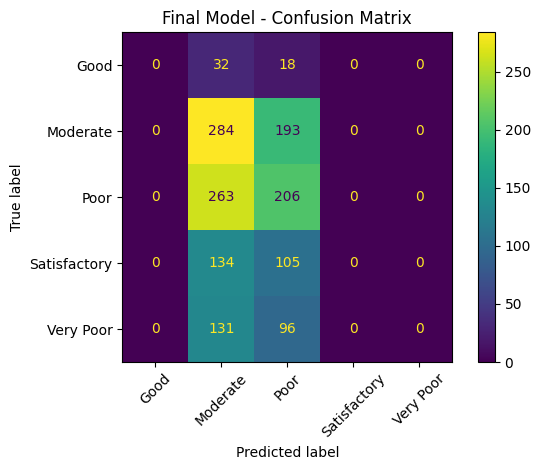

In [23]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred,
    xticks_rotation=45
)

plt.title("Final Model - Confusion Matrix")
plt.tight_layout()
plt.show()

@shap-------------------------------------------------------- 

In [27]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


data ko model ke input form me 

In [28]:
# Get preprocessing and trained model separately
preprocessor_fitted = final_model.named_steps["preprocessor"]
model_fitted = final_model.named_steps["model"]

# Transform training and testing data
X_train_transformed = preprocessor_fitted.transform(X_train)
X_test_transformed = preprocessor_fitted.transform(X_test)

# Get feature names after OneHotEncoding
feature_names = preprocessor_fitted.get_feature_names_out()

print("Original features:", X_train.shape[1])
print("Transformed features:", X_train_transformed.shape[1])
print("\nFirst few transformed features:")
print(feature_names[:20])

Original features: 16
Transformed features: 34

First few transformed features:
['num__Temperature_Max (°C)' 'num__Temperature_Min (°C)'
 'num__Temperature_Avg (°C)' 'num__Humidity (%)' 'num__Rainfall (mm)'
 'num__Wind_Speed (km/h)' 'num__Pressure (hPa)' 'num__Cloud_Cover (%)'
 'num__Year' 'num__Month' 'num__Day' 'num__Day_of_Week'
 'num__Temperature_Range (°C)' 'num__Humidity_Temperature_Index'
 'cat__City_Ahmedabad' 'cat__City_Bengaluru' 'cat__City_Bhopal'
 'cat__City_Chennai' 'cat__City_Delhi' 'cat__City_Hyderabad']


shap apply

In [29]:
explainer = shap.Explainer(
    model_fitted,
    X_train_transformed,
    feature_names=feature_names
)

shap_values = explainer(X_test_transformed)

print("SHAP analysis completed.")

Background dataset has 5848 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5848 when initializing the masker.


SHAP analysis completed.


SHAP values shape: (1462, 34, 5)
Number of SHAP features: 34
Number of feature names: 34

Top Climate Risk Factors:


,Feature,Mean_Absolute_SHAP
3,num__Humidity (%),0.064393
13,num__Humidity_Temperature_Index,0.059030
2,num__Temperature_Avg (°C),0.028186
1,num__Temperature_Min (°C),0.024364
10,num__Day,0.024113
8,num__Year,0.023349
0,num__Temperature_Max (°C),0.021913
11,num__Day_of_Week,0.019832
28,cat__State_Maharashtra,0.019138
23,cat__City_Mumbai,0.019138


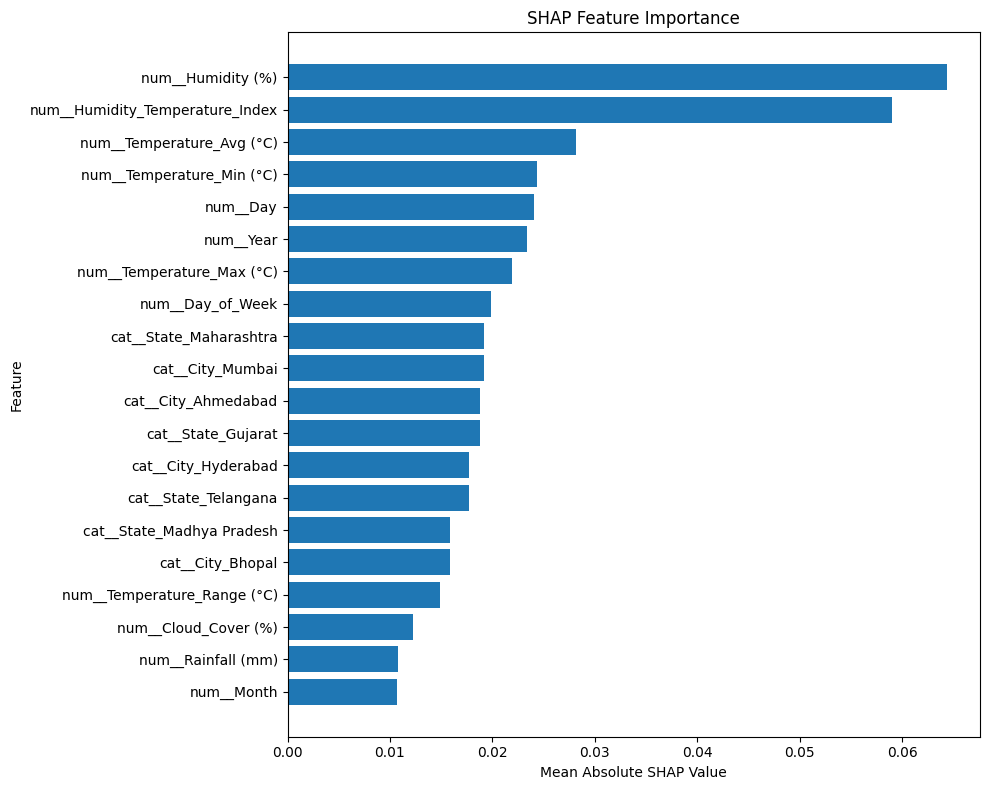

In [33]:
# SHAP Feature Importance - Fixed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get SHAP values
if hasattr(shap_values, "values"):
    values = np.asarray(shap_values.values)
else:
    values = np.asarray(shap_values)

print("SHAP values shape:", values.shape)

# Calculate mean absolute SHAP
# Shape = samples x features x classes
mean_shap = np.abs(values).mean(axis=(0, 2))

# Get feature names from SHAP object/model
if hasattr(shap_values, "feature_names") and shap_values.feature_names is not None:
    feature_names = list(shap_values.feature_names)
else:
    feature_names = list(X_test.columns)

# Make sure feature names match SHAP feature count
print("Number of SHAP features:", len(mean_shap))
print("Number of feature names:", len(feature_names))

# If SHAP has no feature names, use model/X_test names
if len(feature_names) != len(mean_shap):
    feature_names = list(X_test.columns[:len(mean_shap)])

# Create importance table
importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_shap
})

# Sort
importance = importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

# Show top 20
top_features = importance.head(20)

print("\nTop Climate Risk Factors:")
display(top_features)

# Plot
plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Mean_Absolute_SHAP"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

shap summary plot

In [48]:

# SHAP Analysis - Feature Alignment Fix

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Encode TRAIN and TEST together separately
X_train_encoded = pd.get_dummies(
    X_train,
    columns=["City", "State"],
    dtype=float
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=["City", "State"],
    dtype=float
)

# Match TEST columns with TRAIN columns
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print("Encoded X_train:", X_train_encoded.shape)
print("Encoded X_test:", X_test_encoded.shape)
print("Model expected features:", model.n_features_in_)

# Check if features match
assert X_train_encoded.shape[1] == model.n_features_in_, (
    "Encoded features do not match model!"
)

# Background data
background_encoded = shap.sample(
    X_train_encoded,
    50,
    random_state=42
)

# Permutation Explainer
explainer = shap.Explainer(
    model.predict_proba,
    background_encoded,
    algorithm="permutation"
)

# Select test samples
X_shap = X_test_encoded.iloc[:100]

# Calculate SHAP values
shap_values_new = explainer(
    X_shap,
    max_evals=1000
)

print("SHAP values shape:", shap_values_new.values.shape)
print("X_SHAP shape:", X_shap.shape)

Encoded X_train: (5848, 34)
Encoded X_test: (1462, 34)
Model expected features: 34


c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has f

SHAP values shape: (100, 34, 5)
X_SHAP shape: (100, 34)


In [44]:

# Check model and feature shapes

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("Model expected features:", model.n_features_in_)

print("X_shap shape:", X_shap.shape)

# Test model prediction
try:
    prediction = model.predict_proba(X_shap)
    print("Prediction shape:", prediction.shape)
    print("Model prediction working!")
except Exception as e:
    print("Prediction Error:", e)

X_train shape: (5848, 16)
X_test shape: (1462, 16)
Model expected features: 34
X_shap shape: (300, 16)
Prediction Error: could not convert string to float: 'Hyderabad'


c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


In [45]:

# Check categorical columns

print("X_train columns:")
print(X_train.columns.tolist())

print("\nCategorical columns:")
print(X_train.select_dtypes(include=["object"]).columns.tolist())

print("\nModel expected features:", model.n_features_in_)

X_train columns:
['City', 'State', 'Temperature_Max (°C)', 'Temperature_Min (°C)', 'Temperature_Avg (°C)', 'Humidity (%)', 'Rainfall (mm)', 'Wind_Speed (km/h)', 'Pressure (hPa)', 'Cloud_Cover (%)', 'Year', 'Month', 'Day', 'Day_of_Week', 'Temperature_Range (°C)', 'Humidity_Temperature_Index']

Categorical columns:
['City', 'State']

Model expected features: 34


Original SHAP shape: (100, 34, 5)
Summary SHAP shape: (100, 34)
X_SHAP shape: (100, 34)


C:\Users\Hp\AppData\Local\Temp\ipykernel_22784\2022926898.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


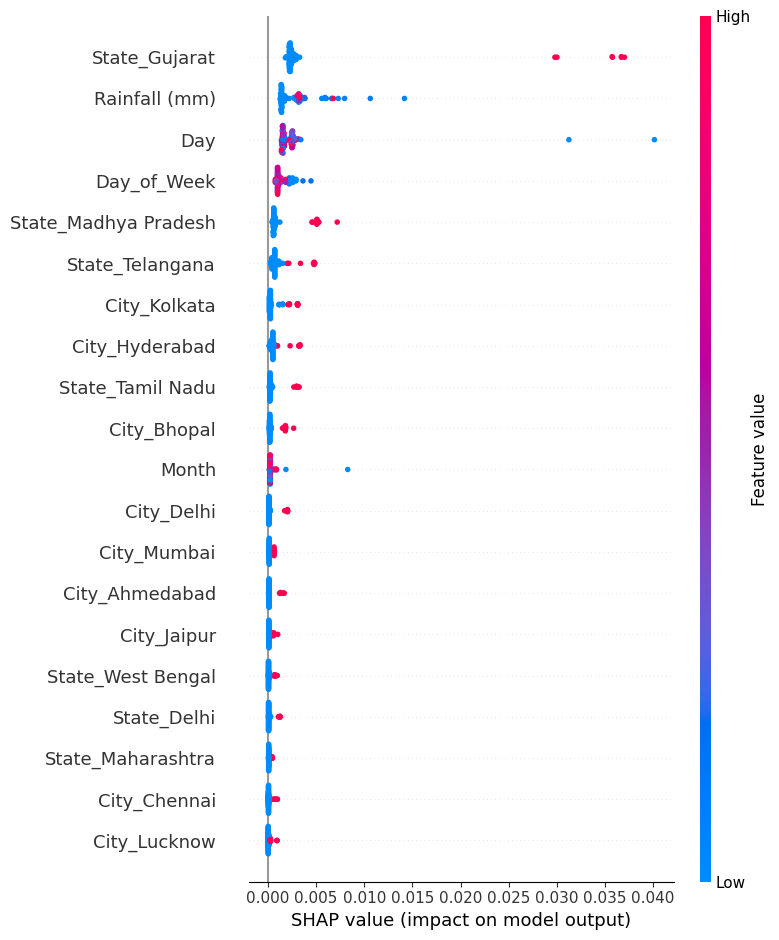

In [49]:

# SHAP Summary Plot - Final

import numpy as np
import shap
import matplotlib.pyplot as plt

# Get SHAP values
sv = shap_values_new.values

print("Original SHAP shape:", sv.shape)

# Multiclass: average absolute SHAP across classes
if sv.ndim == 3:
    shap_summary = np.abs(sv).mean(axis=2)
else:
    shap_summary = sv

print("Summary SHAP shape:", shap_summary.shape)
print("X_SHAP shape:", X_shap.shape)

# Plot
shap.summary_plot(
    shap_summary,
    X_shap,
    feature_names=X_shap.columns,
    max_display=20,
    show=True
)

model evaluation

In [50]:

# Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

# Predictions
y_pred = model.predict(X_test_encoded)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 16.35 %

Classification Report:
              precision    recall  f1-score   support

        Good       0.00      0.00      0.00        50
    Moderate       0.00      0.00      0.00       477
        Poor       0.00      0.00      0.00       469
Satisfactory       0.16      1.00      0.28       239
   Very Poor       0.00      0.00      0.00       227

    accuracy                           0.16      1462
   macro avg       0.03      0.20      0.06      1462
weighted avg       0.03      0.16      0.05      1462



c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\m

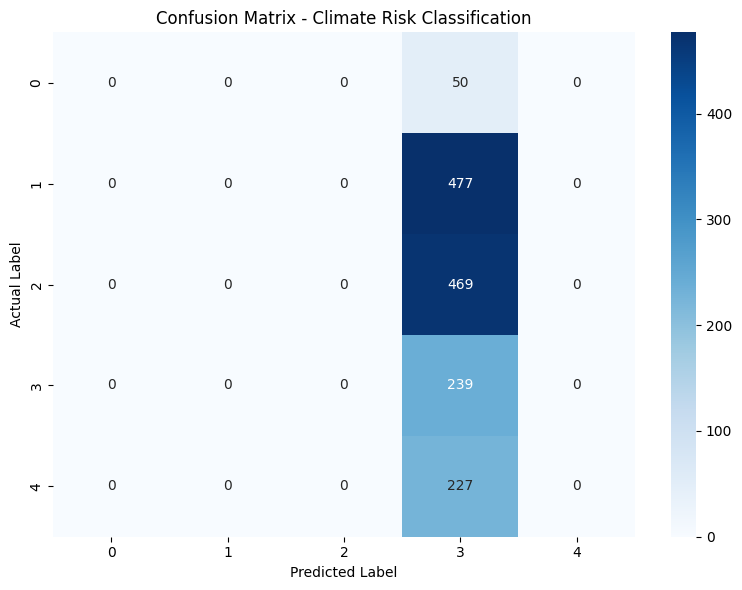

In [51]:

# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Climate Risk Classification")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

SHAP shape: (100, 34, 5)
X_SHAP shape: (100, 34)


C:\Users\Hp\AppData\Local\Temp\ipykernel_22784\2555886776.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


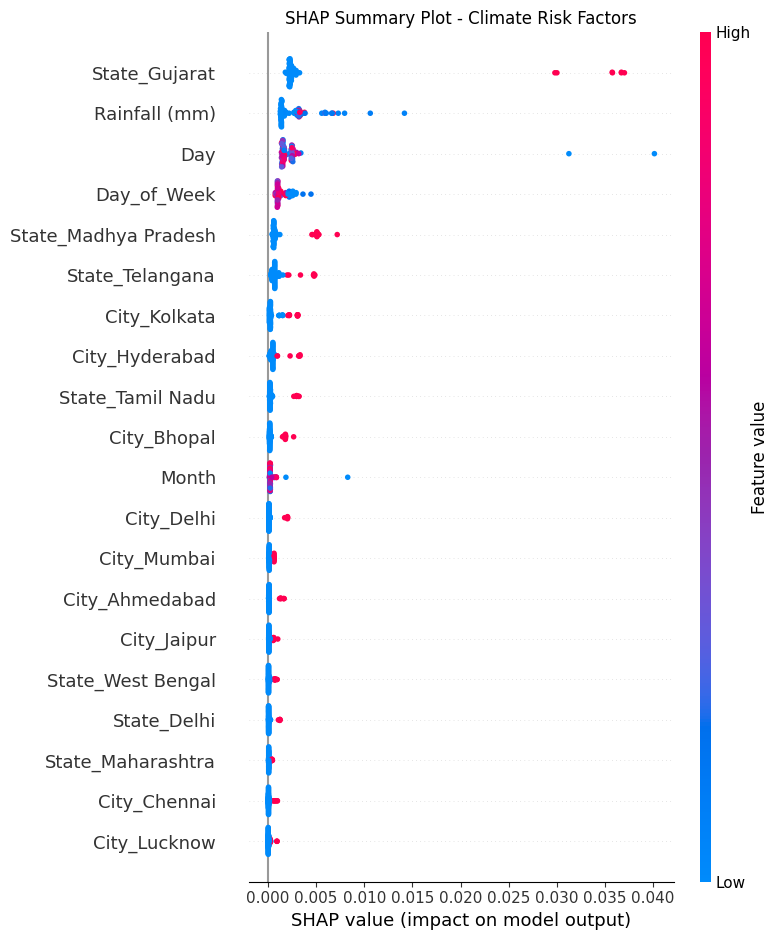

In [55]:
# SHAP Summary Plot - Final Fix

import numpy as np
import matplotlib.pyplot as plt
import shap

# Existing SHAP values
sv = shap_values_new.values

print("SHAP shape:", sv.shape)
print("X_SHAP shape:", X_shap.shape)

# Multiclass: samples x features x classes
if sv.ndim == 3:
    shap_summary = np.abs(sv).mean(axis=2)
else:
    shap_summary = sv

# Summary Plot
shap.summary_plot(
    shap_summary,
    X_shap,
    feature_names=X_shap.columns,
    max_display=20,
    show=False
)

plt.title("SHAP Summary Plot - Climate Risk Factors")
plt.tight_layout()
plt.show()

model evaluation

Model Accuracy: 0.33515731874145005

Classification Report:
              precision    recall  f1-score   support

        Good       0.00      0.00      0.00        50
    Moderate       0.34      0.60      0.43       477
        Poor       0.33      0.44      0.38       469
Satisfactory       0.00      0.00      0.00       239
   Very Poor       0.00      0.00      0.00       227

    accuracy                           0.34      1462
   macro avg       0.13      0.21      0.16      1462
weighted avg       0.22      0.34      0.26      1462



c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

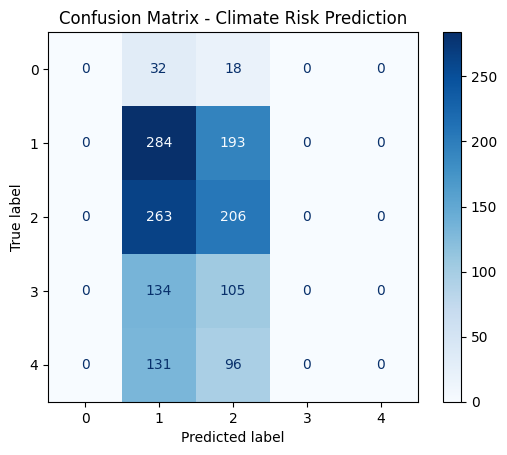

In [57]:
# Model Evaluation - Pipeline Fix

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Use original X_test
y_pred = final_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Climate Risk Prediction")
plt.show()

model ko save karege

In [58]:
# Save Trained Model

import joblib
import os

# Create models folder
os.makedirs("../models", exist_ok=True)

# Save model pipeline
joblib.dump(
    final_model,
    "../models/climate_risk_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


risk prediction testing

In [59]:
# Climate Risk Prediction Testing

import pandas as pd

# Select one sample from test data
sample = X_test.iloc[[0]]

# Predict risk class
prediction = final_model.predict(sample)

print("Predicted Climate Risk:", prediction[0])

# Prediction probabilities
probability = final_model.predict_proba(sample)

print("\nPrediction Probabilities:")
print(probability)

Predicted Climate Risk: Poor

Prediction Probabilities:
[[0.03467358 0.33251192 0.34900605 0.17100059 0.11280787]]


Model Comparison

In [60]:
# Final Model Comparison

print("Model Comparison:")
display(results_df)

Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.335157,0.216717,0.335157,0.261875,0.503806
1,Decision Tree,0.254446,0.252380,0.254446,0.253280,0.493361
2,Gradient Boosting,0.309166,0.236650,0.309166,0.248726,0.494363
3,Random Forest,0.309166,0.224568,0.309166,0.246186,0.504226


In [61]:
# Save Model Comparison

import os

os.makedirs("../results", exist_ok=True)

results_df.to_csv(
    "../results/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


model and final results share karte hai

In [62]:
from pathlib import Path
import joblib

# Project folder identify karo
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

# Folders create
(project_root / "models").mkdir(exist_ok=True)
(project_root / "results").mkdir(exist_ok=True)

# Best trained pipeline save
model_path = project_root / "models" / "climate_risk_model.pkl"
joblib.dump(final_model, model_path)

# Model comparison results save
results_path = project_root / "results" / "model_comparison.csv"
results_df.to_csv(results_path, index=False)

print("Model saved:", model_path)
print("Results saved:", results_path)

Model saved: c:\Users\Hp\Desktop\climate-intelligence-prototype\models\climate_risk_model.pkl
Results saved: c:\Users\Hp\Desktop\climate-intelligence-prototype\results\model_comparison.csv
